# ***Project Title: Customer Transaction Prediction (PRCP-1003)***

# ***1.Problem Statement***

Banks have a large number of customers, but not all customers perform transactions regularly. Identifying customers who are likely to make transactions in the future is important for improving customer engagement and business growth. This project uses historical customer data to analyze customer behavior and develop a predictive model that can identify which customers are likely to make transactions in the future.

### Objective
1) Prepare a complete data analysis report on the given customer transaction dataset.
2) Create a predictive model that helps the bank identify which customers are likely to make transactions in the future.

### Target:
* 0 = No Transaction
* 1 = Transaction

## ***Domain Analysis***
**Domain:** Banking

# ***2.Import Libraries***

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')


# ***3.Load Dataset***

In [4]:
df = pd.read_csv("/content/drive/MyDrive/capstone project/train.csv")

In [5]:
df.head()

,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
0,train_0,0,8.9255,-6.7863,11.9081,5.0930,11.4607,-9.2834,5.1187,18.6266,...,4.4354,3.9642,3.1364,1.6910,18.5227,-2.3978,7.8784,8.5635,12.7803,-1.0914
1,train_1,0,11.5006,-4.1473,13.8588,5.3890,12.3622,7.0433,5.6208,16.5338,...,7.6421,7.7214,2.5837,10.9516,15.4305,2.0339,8.1267,8.7889,18.3560,1.9518
2,train_2,0,8.6093,-2.7457,12.0805,7.8928,10.5825,-9.0837,6.9427,14.6155,...,2.9057,9.7905,1.6704,1.6858,21.6042,3.1417,-6.5213,8.2675,14.7222,0.3965
3,train_3,0,11.0604,-2.1518,8.9522,7.1957,12.5846,-1.8361,5.8428,14.9250,...,4.4666,4.7433,0.7178,1.4214,23.0347,-1.2706,-2.9275,10.2922,17.9697,-8.9996
4,train_4,0,9.8369,-1.4834,12.8746,6.6375,12.2772,2.4486,5.9405,19.2514,...,-1.4905,9.5214,-0.1508,9.1942,13.2876,-1.5121,3.9267,9.5031,17.9974,-8.8104


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
df.shape

(2085, 202)

# ***4.Dataset Overview***

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2085 entries, 0 to 2084
Columns: 202 entries, ID_code to var_199
dtypes: float64(200), int64(1), object(1)
memory usage: 3.2+ MB


In [9]:
df.describe()

,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
count,2085.000000,2085.000000,2085.000000,2085.000000,2085.000000,2085.000000,2085.000000,2085.000000,2085.000000,2085.00000,...,2084.000000,2084.000000,2084.000000,2084.000000,2084.000000,2084.000000,2084.000000,2084.000000,2084.000000,2084.000000
mean,0.097842,10.710646,-1.601709,10.620627,6.853589,11.050390,-5.093224,5.386484,16.643712,0.36238,...,3.391748,7.282951,1.912089,3.271249,18.049675,-0.142062,2.094425,8.911109,15.894273,-3.229224
std,0.297172,3.011167,4.126196,2.598271,2.032169,1.636055,8.059750,0.872486,3.388738,3.32216,...,4.635598,3.009099,1.486791,3.972909,3.183200,1.431719,5.390177,0.941478,2.923198,10.487271
min,0.000000,2.825300,-13.202600,3.678500,1.154100,6.394000,-29.013300,2.897800,8.017000,-7.99420,...,-11.593900,-1.215800,-2.557100,-8.922900,10.791200,-4.488300,-12.325500,6.343300,7.459100,-34.420900
25%,0.000000,8.521500,-4.752000,8.601700,5.300600,9.809600,-11.413600,4.741300,14.085000,-2.26440,...,0.035400,5.021550,0.873700,0.545600,15.604850,-1.190575,-2.201650,8.234475,13.986475,-11.378425
50%,0.000000,10.558100,-1.551600,10.517700,6.882800,11.063700,-5.074400,5.360500,16.621100,0.48080,...,3.457350,7.143000,1.936300,3.323200,18.033400,-0.171300,2.387950,8.895000,15.917850,-2.792750
75%,0.000000,12.730400,1.326800,12.420400,8.389100,12.256900,1.145700,6.006400,19.145100,2.98550,...,6.503275,9.338175,2.945050,6.102650,20.515775,0.845975,6.062400,9.605200,18.069125,5.010950
max,1.000000,19.289300,8.416000,18.347700,12.674000,15.110800,17.251600,7.875500,26.284800,8.48290,...,16.211600,15.686300,6.408000,15.600400,26.097500,3.503500,14.843600,11.701200,24.447900,25.094400


# ***5.Missing Values & Duplicates***

In [10]:
df.isnull().sum()

,0
ID_code,0
target,0
var_0,0
var_1,0
var_2,0
...,...
var_195,1
var_196,1
var_197,1
var_198,1


In [11]:
df.isnull().sum().sum()

np.int64(167)

In [12]:
df.duplicated().sum()

np.int64(0)

# ***6.Target Variable Analysis***

In [13]:
df["target"].value_counts()

,count
target,
0,1881
1,204


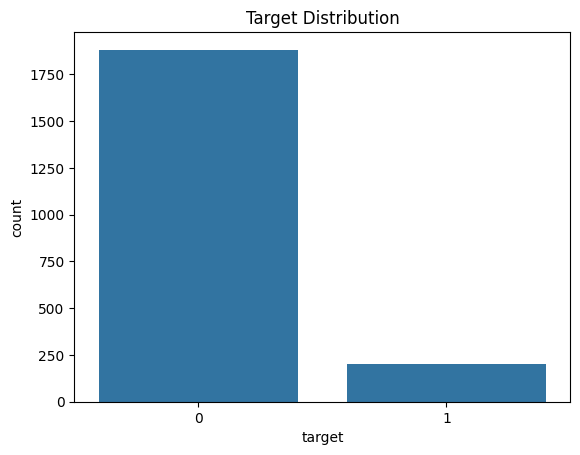

In [14]:
sns.countplot(x='target',data=df)
plt.title("Target Distribution")
plt.show()

# ***7.Percentage Distribution***

In [15]:
target_percent = df["target"].value_counts(normalize=True)*100
print(target_percent)

target
0    90.215827
1     9.784173
Name: proportion, dtype: float64


# ***8.Remove ID Column***

In [16]:
df.drop("ID_code",axis=1,inplace=True)

# ***9.Feature and Target Separation***

In [17]:
X = df.drop("target",axis=1)
y = df["target"]



```
# This is formatted as code
```

# ***10.Train Test Split***

In [18]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=42,
    stratify=y)

# ***Missing Value Handling***

In [35]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

print("Missing values in X_train:", np.isnan(X_train).sum())
print("Missing values in X_test:", np.isnan(X_test).sum())

Missing values in X_train: 0
Missing values in X_test: 0


# ***11.Feature Scaling***

In [36]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ***12.Smote***

In [37]:
smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

# ***13.Model Building***

## A.Logistic Regression

In [38]:
lr = LogisticRegression()
lr.fit(X_train,y_train)
pred_lr = lr.predict(X_test)

In [39]:
print("Accuracy:", accuracy_score(y_test,pred_lr))
print("Precision:", precision_score(y_test,pred_lr))
print("Recall:", recall_score(y_test,pred_lr))
print("F1:",f1_score(y_test,pred_lr))
print("ROC AUC:", roc_auc_score(y_test,pred_lr))

Accuracy: 0.7793764988009593
Precision: 0.22580645161290322
Recall: 0.5121951219512195
F1: 0.31343283582089554
ROC AUC: 0.660352880124546


## 2.Decsion Tree

In [40]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train,y_train)
pred_dt = dt.predict(X_test)

In [41]:
print("Accuracy:", accuracy_score(y_test,pred_dt))
print("Precision:", precision_score(y_test,pred_dt))
print("Recall:", recall_score(y_test,pred_dt))
print("F1:",f1_score(y_test,pred_dt))
print("ROC AUC:", roc_auc_score(y_test,pred_dt))

Accuracy: 0.7577937649880095
Precision: 0.125
Recall: 0.24390243902439024
F1: 0.1652892561983471
ROC AUC: 0.5288661131292164


## 3.Random Forest

In [42]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train,y_train)
pred_rf = rf.predict(X_test)

In [43]:
print("Accuracy:", accuracy_score(y_test,pred_rf))
print("Precision:", precision_score(y_test,pred_rf))
print("Recall:", recall_score(y_test,pred_rf))
print("F1:",f1_score(y_test,pred_rf))
print("ROC AUC:", roc_auc_score(y_test,pred_rf))

Accuracy: 0.8992805755395683
Precision: 0.3333333333333333
Recall: 0.024390243902439025
F1: 0.045454545454545456
ROC AUC: 0.5095355474831343


## 4.Gradient Boosting

In [44]:
gb = GradientBoostingClassifier()
gb.fit(X_train,y_train)
pred_gb = gb.predict(X_test)

In [45]:
print("Accuracy:", accuracy_score(y_test,pred_gb))
print("Precision:", precision_score(y_test,pred_gb))
print("Recall:", recall_score(y_test,pred_gb))
print("F1:",f1_score(y_test,pred_gb))
print("ROC AUC:", roc_auc_score(y_test,pred_gb))

Accuracy: 0.86810551558753
Precision: 0.26666666666666666
Recall: 0.1951219512195122
F1: 0.22535211267605634
ROC AUC: 0.5683056564608199


# ***14.Model Comparison Table***

In [46]:
results = pd.DataFrame({
    'Model':["Logidtic Regression",
             "Decision Tree",
             "Random Forest",
             "Gradient Boosting"],

    "Accuracy":[accuracy_score(y_test,pred_lr),
                accuracy_score(y_test,pred_dt),
                accuracy_score(y_test,pred_rf),
                accuracy_score(y_test,pred_gb)],

    "F1 Score":[f1_score(y_test,pred_lr),
                f1_score(y_test,pred_dt),
                f1_score(y_test,pred_rf),
                f1_score(y_test,pred_gb)],

    "ROC AUC":[roc_auc_score(y_test,pred_lr),
               roc_auc_score(y_test,pred_dt),
               roc_auc_score(y_test,pred_rf),
               roc_auc_score(y_test,pred_gb)]
})

results


,Model,Accuracy,F1 Score,ROC AUC
0,Logidtic Regression,0.779376,0.313433,0.660353
1,Decision Tree,0.757794,0.165289,0.528866
2,Random Forest,0.899281,0.045455,0.509536
3,Gradient Boosting,0.868106,0.225352,0.568306


# ***15.Confusion Martix***

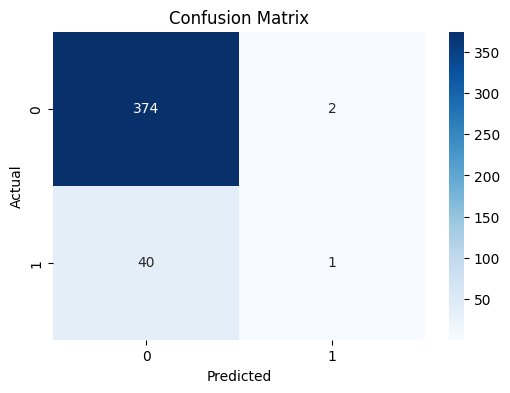

In [47]:
cm = confusion_matrix(y_test,pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ***16.Classification Report***

In [48]:
print(classification_report(y_test, pred_rf))

              precision    recall  f1-score   support

           0       0.90      0.99      0.95       376
           1       0.33      0.02      0.05        41

    accuracy                           0.90       417
   macro avg       0.62      0.51      0.50       417
weighted avg       0.85      0.90      0.86       417



# ***17.Hyperparameter Tuning***

In [49]:
param_grid = {
    'n_estimators':[100,200],
    'max_depth':[5,10,None]
}

grid = GridSearchCV(
    RandomForestClassifier(),
    param_grid,
    cv=5,
    scoring='roc_auc'
)

grid.fit(X_train,y_train)

print(grid.best_params_)

{'max_depth': None, 'n_estimators': 200}


# ***18.Final Model***

In [50]:
best_rf = RandomForestClassifier(
n_estimators=200,
max_depth=10,
random_state=42
)

best_rf.fit(X_train,y_train)

final_pred = best_rf.predict(X_test)

# ***19.Cross Validation***

In [51]:
cv_scores = cross_val_score(
    best_rf,X_train,y_train,cv=5,scoring="roc_auc")

print(cv_scores)

print("average ROC AUC:",cv_scores.mean())

[0.99280361 0.99953643 0.99945917 0.99915012 0.99934879]
average ROC AUC: 0.9980596240659596


# ***20.Feature Importance***

In [52]:
importance = best_rf.feature_importances_

features = X.columns

feature_importance = pd.DataFrame({
    'Feature':features,
    'Importance':importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
67,var_67,0.033420
164,var_164,0.029914
36,var_36,0.027757
116,var_116,0.020834
59,var_59,0.020511
105,var_105,0.016710
110,var_110,0.016179
33,var_33,0.016019
62,var_62,0.014017
169,var_169,0.013089


# ***21.Business Insights***

1) 90% of customers do not perform transaction.
2) Only a small group of customers actively respond to banking offers.
3) Only 10% of customers are likely to make transactions.
4) These customers are important for increasing bank revenue.
5) The model helps identify customers who are more likely to respond.
6) The model helps to find customers interested in banking products.
7) The dataset is highly imbalanced.
8) The bank can reduce marketing costs by focusing on likely customers.
9) Customer behavior can be predicted using historical data.
10) Machine learning helps improve decision-making.

# ***22.Challenges Faced***

**1. Anonymous Features**

* Challenge: The dataset contains 200 features with names like var_0, var_1, etc., making it difficult to understand their real meaning.

* Solution: Statistical analysis, correlation analysis, and feature importance techniques were used to understand the impact of features.

**2. Imbalanced Dataset**

* Challenge: Around 90% of customers belong to class 0 and only 10% belong to class 1, which can bias the model.

* Solution: Evaluation metrics such as Recall, F1-Score, and ROC-AUC were used, and balancing techniques like SMOTE can be applied.

**3. High Dimensional Data**

* Challenge: The dataset contains 200 features, increasing model complexity and training time.

* Solution: Feature importance analysis was performed to identify the most influential features.

**4. Risk of Overfitting**

* Challenge: Complex models may memorize training data and perform poorly on unseen data.

* Solution: Train-test split, cross-validation, and hyperparameter tuning were used to improve generalization.

**5. Model Selection**

* Challenge: Multiple machine learning algorithms produced different results, making model selection difficult.

* Solution: Models were compared using Accuracy, Precision, Recall, F1-Score, and ROC-AUC Score to select the best-performing model.

**6. Feature Scaling Requirement**

* Challenge: Features had different numerical ranges, which could affect model performance.

* Solution: StandardScaler was applied to normalize feature values before training.

**7. Identifying Minority-Class Customers**

* Challenge: Customers who perform transactions represent only a small portion of the dataset.

* Solution: Focus was placed on Recall and ROC-AUC Score to improve identification of potential transaction customers.


# ***23.Conclusion***

The goal of this project was to predict whether a customer will make a transaction or not. Different machine learning models were built and compared to find the best-performing model.

The dataset was analyzed, cleaned, and prepared before model training. The selected model showed good performance in identifying potential customers.

This model can help banks target the right customers, reduce marketing costs, improve campaign success rates, and increase business profit. Therefore, machine learning can be effectively used to support customer transaction prediction and improve business decision-making.